In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

# Better Visualization Style

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [55]:
df = pd.read_csv("dataset/loan_data.csv")

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [57]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [58]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

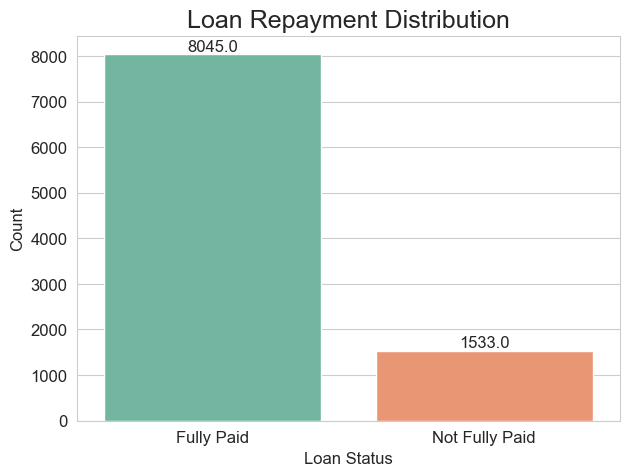

In [59]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='not.fully.paid',
    data=df,
    palette='Set2'
)

# Add Labels

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title("Loan Repayment Distribution", fontsize=18)

plt.xticks(
    [0,1],
    ['Fully Paid', 'Not Fully Paid']
)

plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

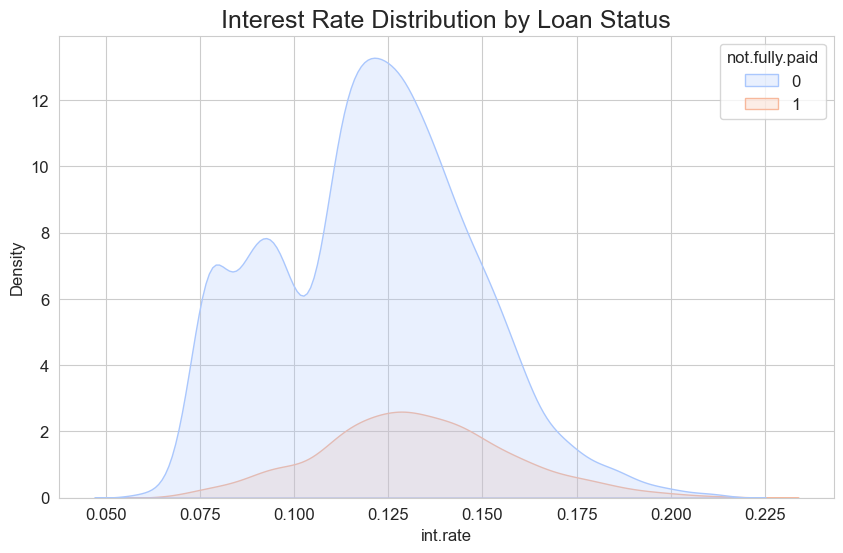

In [60]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='int.rate',
    hue='not.fully.paid',
    fill=True,
    palette='coolwarm'
)

plt.title("Interest Rate Distribution by Loan Status", fontsize=18)

plt.show()

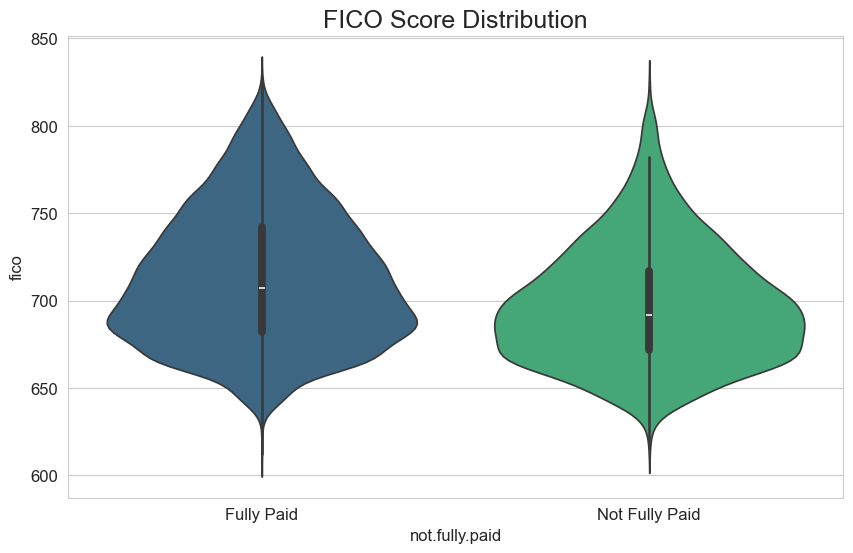

In [61]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='not.fully.paid',
    y='fico',
    data=df,
    palette='viridis'
)

plt.xticks(
    [0,1],
    ['Fully Paid', 'Not Fully Paid']
)

plt.title("FICO Score Distribution", fontsize=18)

plt.show()


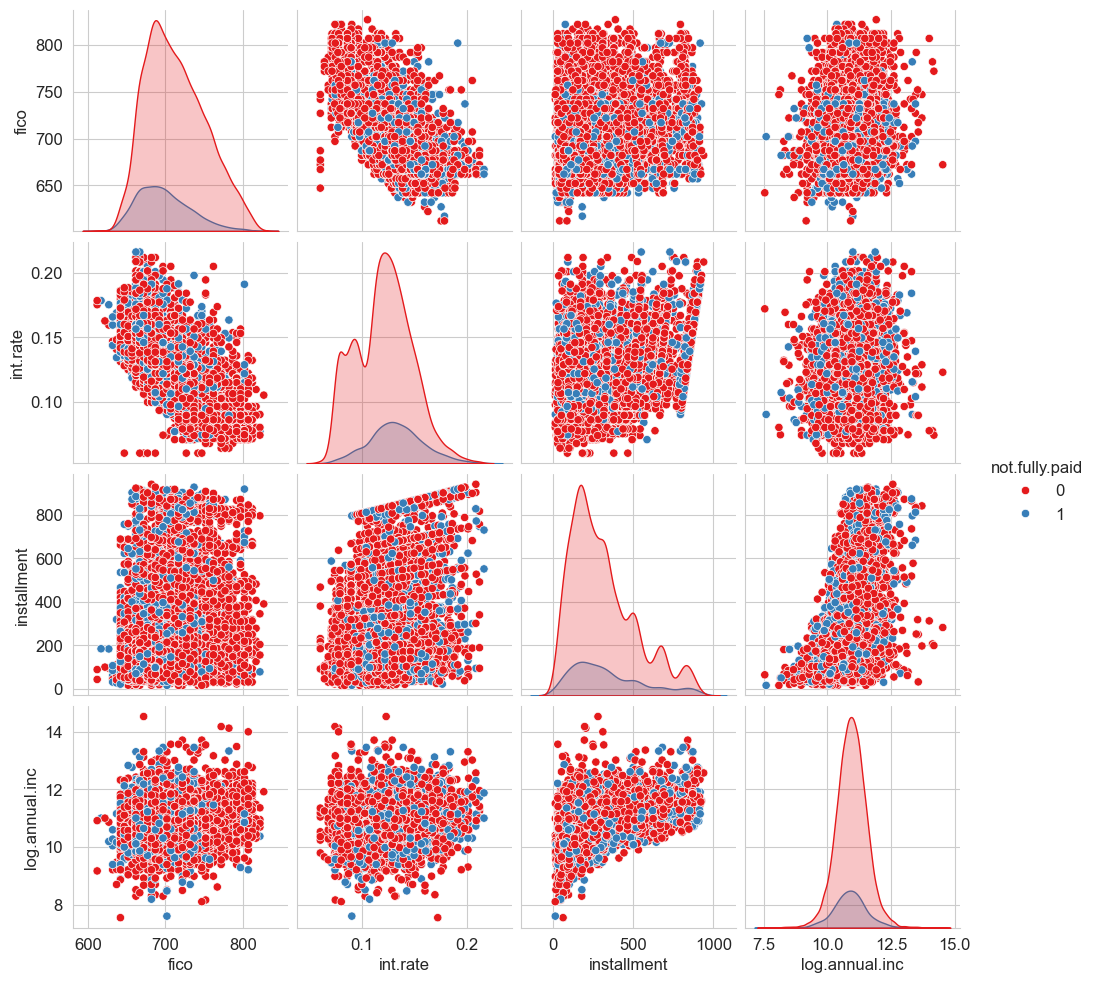

In [62]:
sns.pairplot(
    df[
        [
            'fico',
            'int.rate',
            'installment',
            'log.annual.inc',
            'not.fully.paid'
        ]
    ],
    hue='not.fully.paid',
    palette='Set1'
)

plt.show()

In [63]:
temp_df = df.copy()

encoder = LabelEncoder()

temp_df['purpose'] = encoder.fit_transform(
    temp_df['purpose']
)

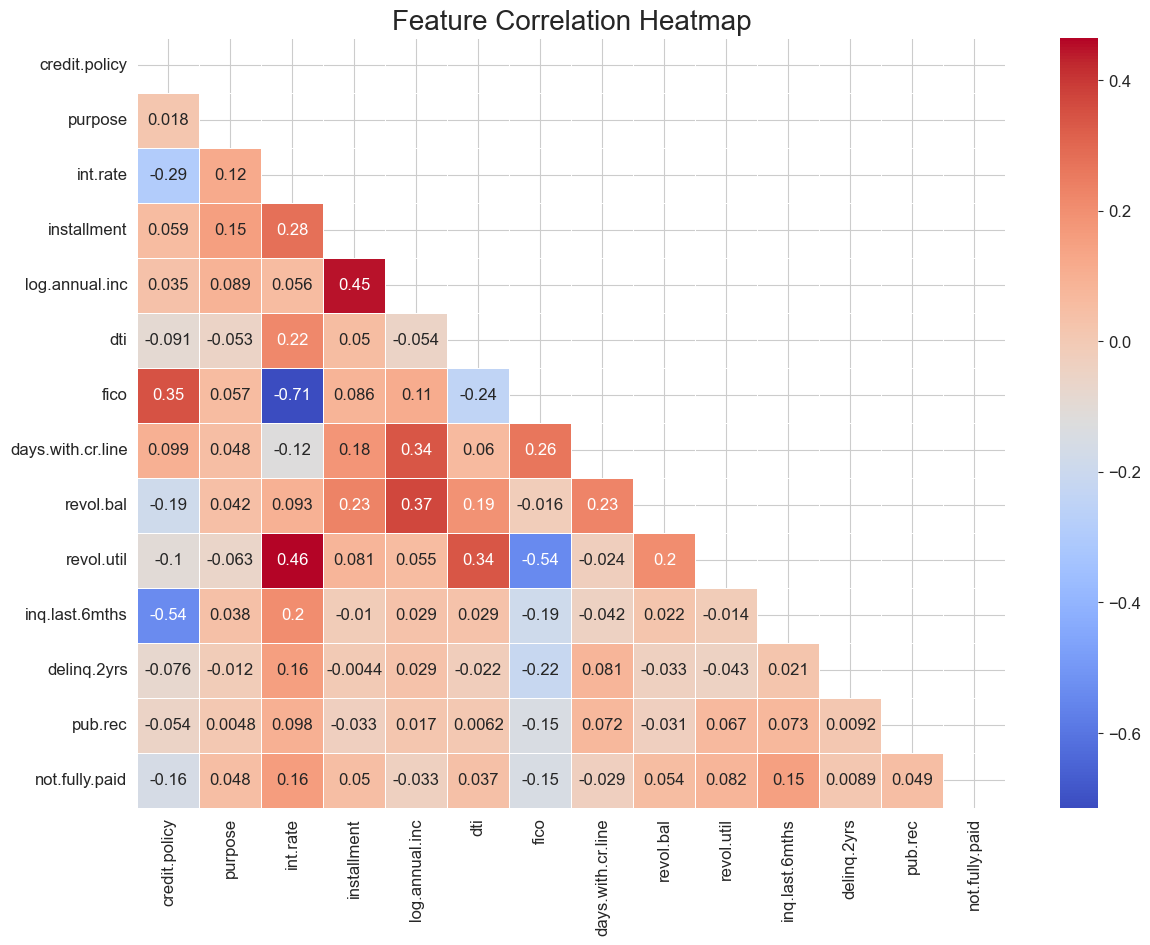

In [64]:
plt.figure(figsize=(14,10))

corr = temp_df.corr()

mask = np.triu(np.ones_like(corr))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=20)

plt.show()

In [65]:
# Feature Selection

X = df.drop('not.fully.paid', axis=1)

y = df['not.fully.paid']

print(X.shape)
print(y.shape)

(9578, 13)
(9578,)


In [66]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = encoder.fit_transform(df[col])

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [67]:
# Features and Target

X = df.drop('not.fully.paid', axis=1)

y = df['not.fully.paid']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [69]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [70]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Random Forest Accuracy :", rf_accuracy)
print("Logistic Regression Accuracy :", lr_accuracy)

Random Forest Accuracy : 0.8392484342379958
Logistic Regression Accuracy : 0.8397703549060542


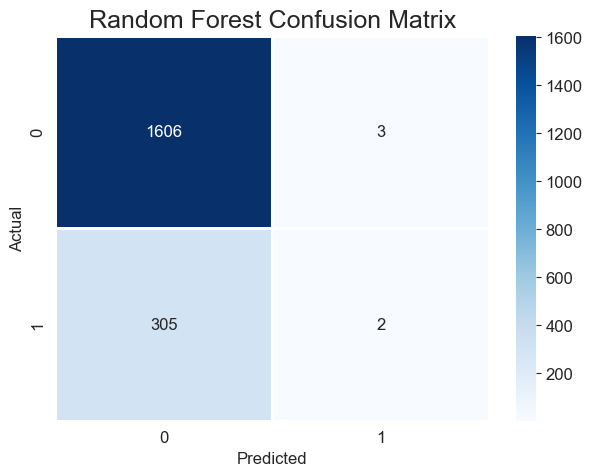

In [73]:
plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1
)

plt.title("Random Forest Confusion Matrix", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

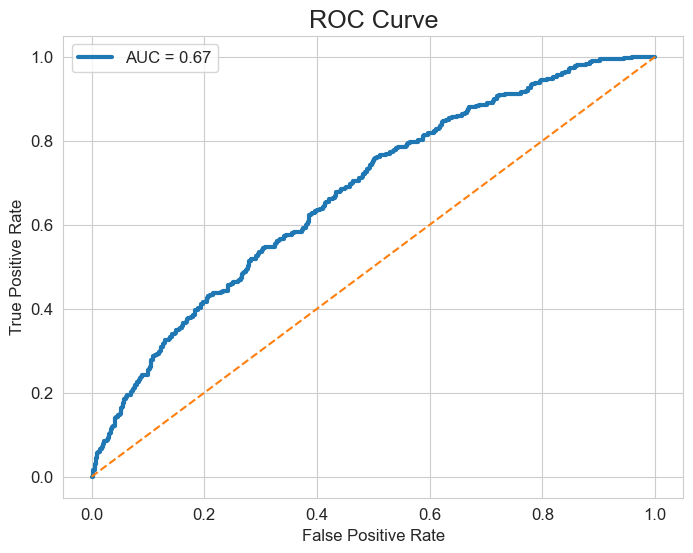

In [74]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

auc_score = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.2f}',
    linewidth=3
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve", fontsize=18)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

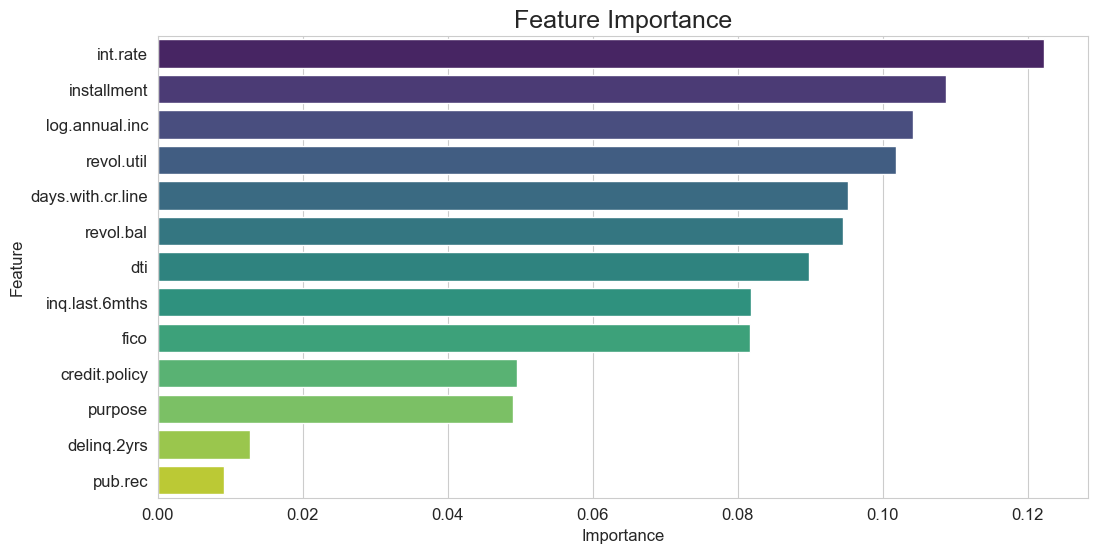

In [75]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='viridis'
)

plt.title("Feature Importance", fontsize=18)

plt.show()